In [2]:
import os
import re
import pandas as pd
from collections import defaultdict

BASE_DIR = "results_docking"

# regex to capture vina affinity lines
affinity_pattern = re.compile(r"^\s*1\s+(-?\d+\.\d+)\s+")

data = []

for protein in os.listdir(BASE_DIR):
    protein_path = os.path.join(BASE_DIR, protein)
    if not os.path.isdir(protein_path):
        continue

    for ligand in os.listdir(protein_path):
        ligand_path = os.path.join(protein_path, ligand)
        if not os.path.isdir(ligand_path):
            continue

        for file in os.listdir(ligand_path):
            if not file.endswith(".log"):
                continue

            log_path = os.path.join(ligand_path, file)

            # extract replicate number if exists
            rep_match = re.search(r"rep(\d+)", file)
            rep = int(rep_match.group(1)) if rep_match else None

            affinity = None

            with open(log_path, "r") as f:
                for line in f:
                    m = affinity_pattern.match(line)
                    if m:
                        affinity = float(m.group(1))
                        break

            if affinity is not None:
                data.append({
                    "protein": protein,
                    "ligand": ligand,
                    "replicate": rep,
                    "affinity": affinity
                })

df = pd.DataFrame(data)


In [2]:
df["ligand"].unique()


array(['10176710', '10394', '104775', '10559720', '107', '175', '348154',
       '439435', '49831816', '6262', '689043', '9877619', 'm1', 'm2',
       'm3', 'm4', 'm5', 'rf', 'rolR', 'rolS'], dtype=object)

In [3]:
# ---- per ligand mean/std ----
summary = (
    df.groupby(["protein", "ligand"])
      .agg(mean_affinity=("affinity", "mean"),
           std_affinity=("affinity", "std"),
           n=("affinity", "count"))
      .reset_index()
)

In [4]:
df.to_csv("vina_replicates.csv", index=False)
summary.to_csv("vina_summary.csv", index=False)

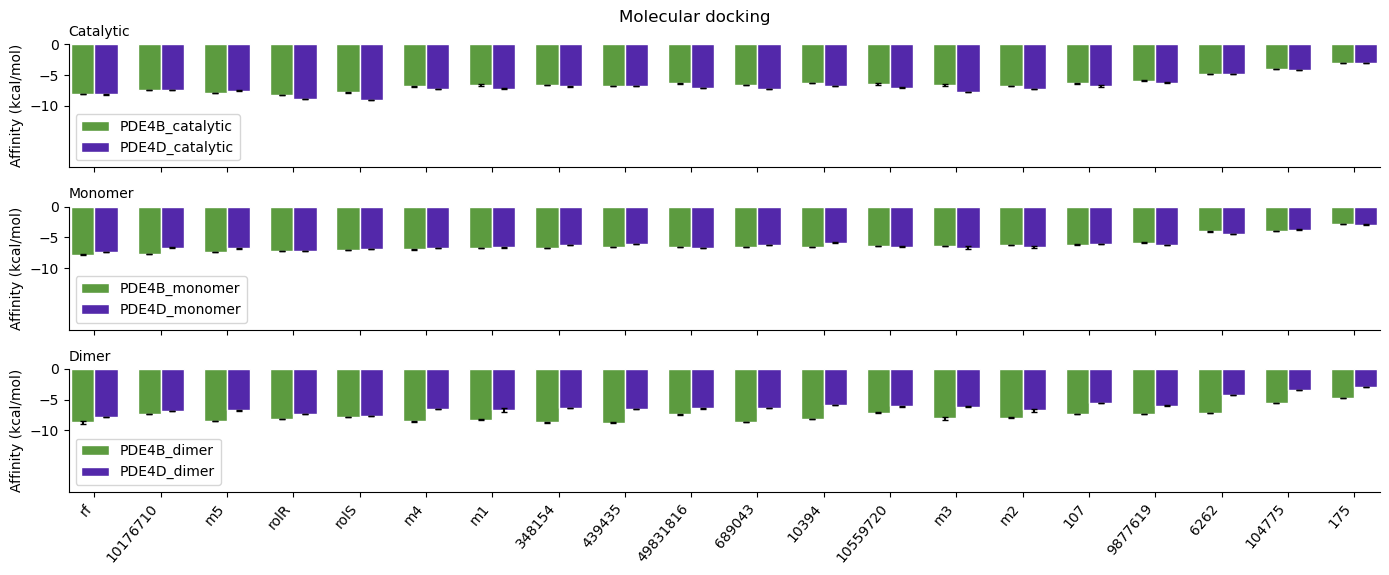

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# colors = {
#     "PDE4B_catalytic": "#a9d5a8",
#     "PDE4B_monomer": "#5c9b3f",
#     "PDE4B_dimer": "#306317",
#     "PDE4D_catalytic": "#9ea9e2",
#     "PDE4D_monomer": "#5328aa",
#     "PDE4D_dimer": "#2b0b63",
# }

colors = {
    "PDE4B_catalytic": "#5c9b3f",
    "PDE4B_monomer": "#5c9b3f",
    "PDE4B_dimer": "#5c9b3f",
    "PDE4D_catalytic": "#5328aa",
    "PDE4D_monomer": "#5328aa",
    "PDE4D_dimer": "#5328aa",
}

comparisons = [
    ("Catalytic", "PDE4B_catalytic", "PDE4D_catalytic"),
    ("Monomer", "PDE4B_monomer", "PDE4D_monomer"),
    ("Dimer", "PDE4B_dimer", "PDE4D_dimer"),
]

# Order ligands based on PDE4D_catalytic affinity: lowest → highest
# ligands = (
#     summary[summary["protein"] == "PDE4D_catalytic"]
#     .sort_values("mean_affinity", ascending=True)["ligand"]
#     .tolist()
# )
ligands = (
    summary[summary["protein"] == "PDE4B_monomer"]
    .sort_values("mean_affinity", ascending=True)["ligand"]
    .tolist()
)

x = np.arange(len(ligands))
width = 0.35

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 6),
    sharex=True,
    #gridspec_kw={"height_ratios": [1.5, 1.5, 2]}
)

for ax, (title, protein_b, protein_d) in zip(axes, comparisons):

    for i, protein in enumerate([protein_b, protein_d]):

        sub = (
            summary[summary["protein"] == protein]
            .set_index("ligand")
            .reindex(ligands)
        )

        ax.bar(
            x + (i - 0.5) * width,
            sub["mean_affinity"],
            width,
            yerr=sub["std_affinity"],
            capsize=2,
            label=protein,
            color=colors[protein],
            edgecolor="white",
            linewidth=1
        )
    ax.set_ylim(-20, 0)
    ax.set_yticks(np.arange(-10, 1, 5))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.margins(x=0.002)
    ax.set_ylabel("Affinity (kcal/mol)")
    ax.set_title(title, loc="left", fontsize=10)
    
    ax.legend(fontsize=10)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(ligands, rotation=50, ha="right")

fig.suptitle("Molecular docking", y=0.95)
plt.tight_layout()
plt.show()

In [12]:
summary[summary["ligand"] == "m5"]

,protein,ligand,mean_affinity,std_affinity,n
16,PDE4B_catalytic,m5,-7.900000,0.000000,3
36,PDE4B_dimer,m5,-8.400000,0.000000,3
56,PDE4B_monomer,m5,-7.400000,0.000000,3
76,PDE4D_catalytic,m5,-7.533333,0.057735,3
96,PDE4D_dimer,m5,-6.766667,0.057735,3
116,PDE4D_monomer,m5,-6.766667,0.057735,3


In [13]:
summary[summary["ligand"] == "10176710"]

,protein,ligand,mean_affinity,std_affinity,n
0,PDE4B_catalytic,10176710,-7.400000,0.000000,3
20,PDE4B_dimer,10176710,-7.400000,0.000000,3
40,PDE4B_monomer,10176710,-7.700000,0.000000,3
60,PDE4D_catalytic,10176710,-7.500000,0.000000,3
80,PDE4D_dimer,10176710,-6.900000,0.000000,3
100,PDE4D_monomer,10176710,-6.666667,0.057735,3


/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after s

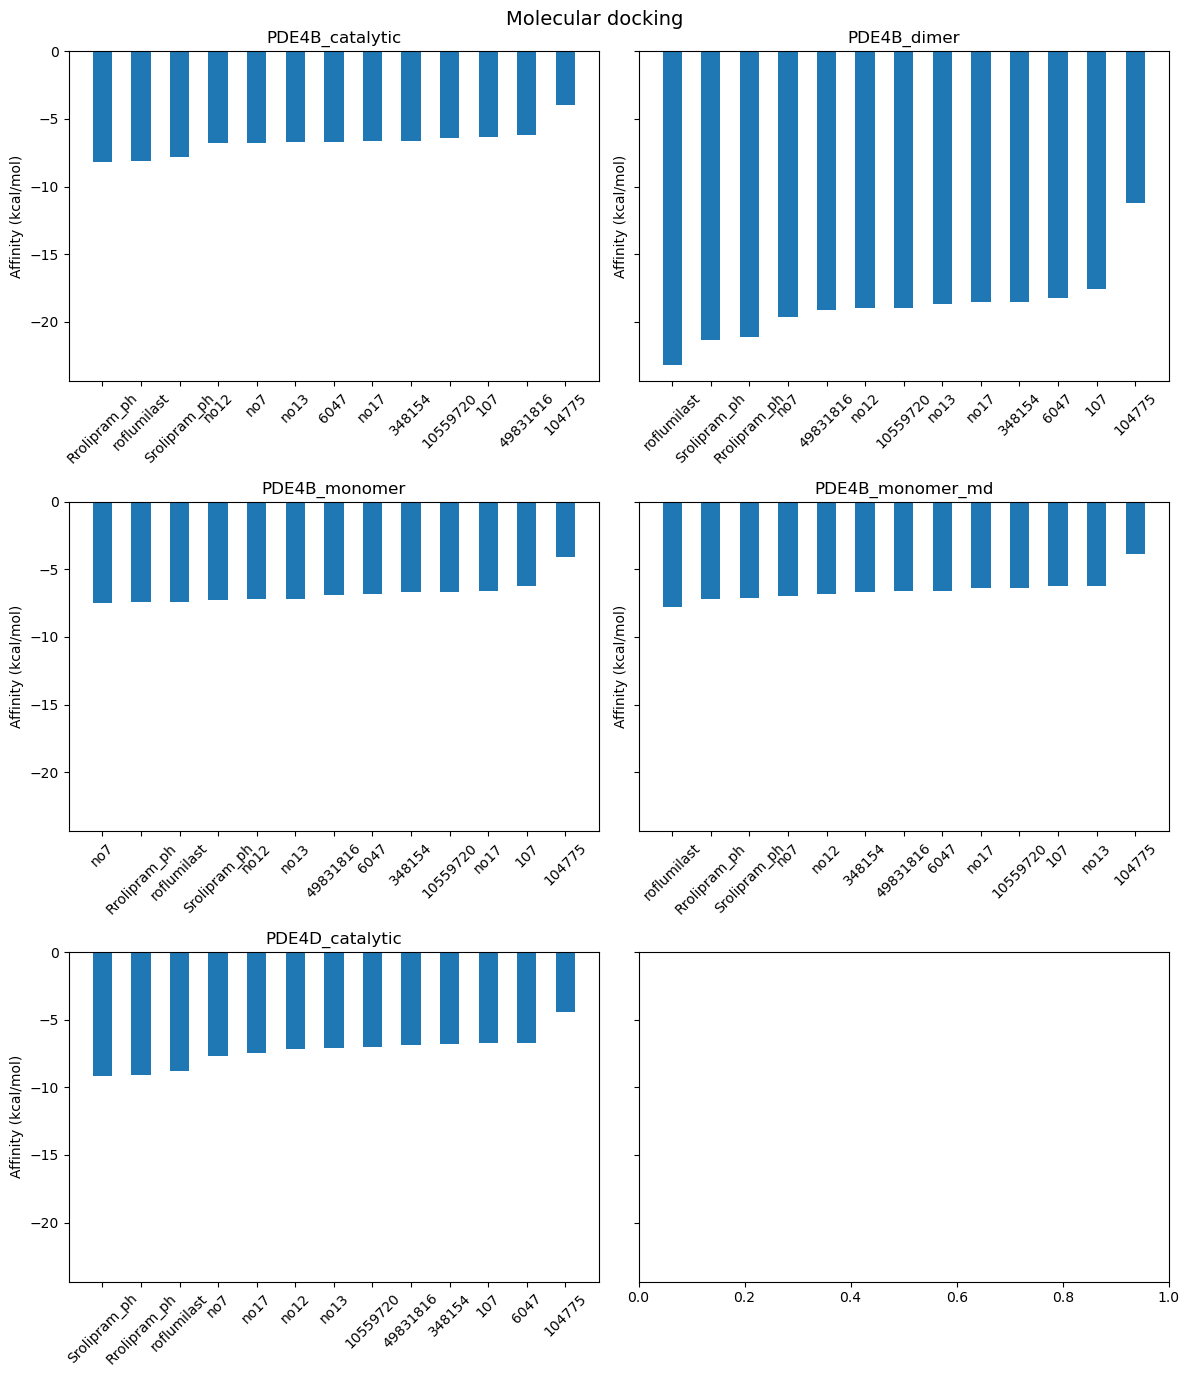

In [38]:
import matplotlib.pyplot as plt

df_rep1 = df[df["replicate"] == 1]

fig, axes = plt.subplots(3, 2, figsize=(10, 14), sharey=True)
axes = axes.ravel()

proteins = df_rep1["protein"].unique()
#proteins = df[df["protein"] != "PDE4B_monomer_md"]["protein"].unique()

for ax, protein in zip(axes, proteins):
    sub = df_rep1[df_rep1["protein"] == protein].sort_values("affinity")
    ax.bar(sub["ligand"], sub["affinity"], width=0.5)
    ax.set_title(protein)
    ax.set_xticklabels(sub["ligand"], rotation=45)
    ax.set_ylabel("Affinity (kcal/mol)")

fig.suptitle("Molecular docking", fontsize=14)
plt.tight_layout()
plt.show()